# Title : Building an AI-Powered Predictive Model of Credit_Card_Fraud_Detection

### Step 1) Import Necessary Libraries

In [225]:
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings("ignore")

### Step 2) Data Collection 

In [226]:
df=pd.read_csv(r"C:\Users\rambr\Downloads\fraudTest.csv.zip")
df

,Unnamed: 0,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,...,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
0,0,2020-06-21 12:14:25,2291163933867244,fraud_Kirlin and Sons,personal_care,2.86,Jeff,Elliott,M,351 Darlene Green,...,33.9659,-80.9355,333497,Mechanical engineer,1968-03-19,2da90c7d74bd46a0caf3777415b3ebd3,1371816865,33.986391,-81.200714,0
1,1,2020-06-21 12:14:33,3573030041201292,fraud_Sporer-Keebler,personal_care,29.84,Joanne,Williams,F,3638 Marsh Union,...,40.3207,-110.4360,302,"Sales professional, IT",1990-01-17,324cc204407e99f51b0d6ca0055005e7,1371816873,39.450498,-109.960431,0
2,2,2020-06-21 12:14:53,3598215285024754,"fraud_Swaniawski, Nitzsche and Welch",health_fitness,41.28,Ashley,Lopez,F,9333 Valentine Point,...,40.6729,-73.5365,34496,"Librarian, public",1970-10-21,c81755dbbbea9d5c77f094348a7579be,1371816893,40.495810,-74.196111,0
3,3,2020-06-21 12:15:15,3591919803438423,fraud_Haley Group,misc_pos,60.05,Brian,Williams,M,32941 Krystal Mill Apt. 552,...,28.5697,-80.8191,54767,Set designer,1987-07-25,2159175b9efe66dc301f149d3d5abf8c,1371816915,28.812398,-80.883061,0
4,4,2020-06-21 12:15:17,3526826139003047,fraud_Johnston-Casper,travel,3.19,Nathan,Massey,M,5783 Evan Roads Apt. 465,...,44.2529,-85.0170,1126,Furniture designer,1955-07-06,57ff021bd3f328f8738bb535c302a31b,1371816917,44.959148,-85.884734,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
555714,555714,2020-12-31 23:59:07,30560609640617,fraud_Reilly and Sons,health_fitness,43.77,Michael,Olson,M,558 Michael Estates,...,40.4931,-91.8912,519,Town planner,1966-02-13,9b1f753c79894c9f4b71f04581835ada,1388534347,39.946837,-91.333331,0
555715,555715,2020-12-31 23:59:09,3556613125071656,fraud_Hoppe-Parisian,kids_pets,111.84,Jose,Vasquez,M,572 Davis Mountains,...,29.0393,-95.4401,28739,Futures trader,1999-12-27,2090647dac2c89a1d86c514c427f5b91,1388534349,29.661049,-96.186633,0
555716,555716,2020-12-31 23:59:15,6011724471098086,fraud_Rau-Robel,kids_pets,86.88,Ann,Lawson,F,144 Evans Islands Apt. 683,...,46.1966,-118.9017,3684,Musician,1981-11-29,6c5b7c8add471975aa0fec023b2e8408,1388534355,46.658340,-119.715054,0
555717,555717,2020-12-31 23:59:24,4079773899158,fraud_Breitenberg LLC,travel,7.99,Eric,Preston,M,7020 Doyle Stream Apt. 951,...,44.6255,-116.4493,129,Cartographer,1965-12-15,14392d723bb7737606b2700ac791b7aa,1388534364,44.470525,-117.080888,0


### Step 3) Data Understanding

In [227]:
#1)To check the dataset shape
df.shape

(555719, 23)

In [228]:
#2)to check the first 5 rows
df.head()

,Unnamed: 0,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,...,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
0,0,2020-06-21 12:14:25,2291163933867244,fraud_Kirlin and Sons,personal_care,2.86,Jeff,Elliott,M,351 Darlene Green,...,33.9659,-80.9355,333497,Mechanical engineer,1968-03-19,2da90c7d74bd46a0caf3777415b3ebd3,1371816865,33.986391,-81.200714,0
1,1,2020-06-21 12:14:33,3573030041201292,fraud_Sporer-Keebler,personal_care,29.84,Joanne,Williams,F,3638 Marsh Union,...,40.3207,-110.4360,302,"Sales professional, IT",1990-01-17,324cc204407e99f51b0d6ca0055005e7,1371816873,39.450498,-109.960431,0
2,2,2020-06-21 12:14:53,3598215285024754,"fraud_Swaniawski, Nitzsche and Welch",health_fitness,41.28,Ashley,Lopez,F,9333 Valentine Point,...,40.6729,-73.5365,34496,"Librarian, public",1970-10-21,c81755dbbbea9d5c77f094348a7579be,1371816893,40.495810,-74.196111,0
3,3,2020-06-21 12:15:15,3591919803438423,fraud_Haley Group,misc_pos,60.05,Brian,Williams,M,32941 Krystal Mill Apt. 552,...,28.5697,-80.8191,54767,Set designer,1987-07-25,2159175b9efe66dc301f149d3d5abf8c,1371816915,28.812398,-80.883061,0
4,4,2020-06-21 12:15:17,3526826139003047,fraud_Johnston-Casper,travel,3.19,Nathan,Massey,M,5783 Evan Roads Apt. 465,...,44.2529,-85.0170,1126,Furniture designer,1955-07-06,57ff021bd3f328f8738bb535c302a31b,1371816917,44.959148,-85.884734,0


In [229]:
#3)to check the last five rows
df.tail()

,Unnamed: 0,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,...,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
555714,555714,2020-12-31 23:59:07,30560609640617,fraud_Reilly and Sons,health_fitness,43.77,Michael,Olson,M,558 Michael Estates,...,40.4931,-91.8912,519,Town planner,1966-02-13,9b1f753c79894c9f4b71f04581835ada,1388534347,39.946837,-91.333331,0
555715,555715,2020-12-31 23:59:09,3556613125071656,fraud_Hoppe-Parisian,kids_pets,111.84,Jose,Vasquez,M,572 Davis Mountains,...,29.0393,-95.4401,28739,Futures trader,1999-12-27,2090647dac2c89a1d86c514c427f5b91,1388534349,29.661049,-96.186633,0
555716,555716,2020-12-31 23:59:15,6011724471098086,fraud_Rau-Robel,kids_pets,86.88,Ann,Lawson,F,144 Evans Islands Apt. 683,...,46.1966,-118.9017,3684,Musician,1981-11-29,6c5b7c8add471975aa0fec023b2e8408,1388534355,46.658340,-119.715054,0
555717,555717,2020-12-31 23:59:24,4079773899158,fraud_Breitenberg LLC,travel,7.99,Eric,Preston,M,7020 Doyle Stream Apt. 951,...,44.6255,-116.4493,129,Cartographer,1965-12-15,14392d723bb7737606b2700ac791b7aa,1388534364,44.470525,-117.080888,0
555718,555718,2020-12-31 23:59:34,4170689372027579,fraud_Dare-Marvin,entertainment,38.13,Samuel,Frey,M,830 Myers Plaza Apt. 384,...,35.6665,-97.4798,116001,Media buyer,1993-05-10,1765bb45b3aa3224b4cdcb6e7a96cee3,1388534374,36.210097,-97.036372,0


In [230]:
#4)Information about data and to check the data types
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 555719 entries, 0 to 555718
Data columns (total 23 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   Unnamed: 0             555719 non-null  int64  
 1   trans_date_trans_time  555719 non-null  object 
 2   cc_num                 555719 non-null  int64  
 3   merchant               555719 non-null  object 
 4   category               555719 non-null  object 
 5   amt                    555719 non-null  float64
 6   first                  555719 non-null  object 
 7   last                   555719 non-null  object 
 8   gender                 555719 non-null  object 
 9   street                 555719 non-null  object 
 10  city                   555719 non-null  object 
 11  state                  555719 non-null  object 
 12  zip                    555719 non-null  int64  
 13  lat                    555719 non-null  float64
 14  long                   555719 non-nu

In [231]:
#5)Understanding feature names/columns
df.columns

Index(['Unnamed: 0', 'trans_date_trans_time', 'cc_num', 'merchant', 'category',
       'amt', 'first', 'last', 'gender', 'street', 'city', 'state', 'zip',
       'lat', 'long', 'city_pop', 'job', 'dob', 'trans_num', 'unix_time',
       'merch_lat', 'merch_long', 'is_fraud'],
      dtype='object')

In [232]:
#6)detailed statistical summary
df.describe()

,Unnamed: 0,cc_num,amt,zip,lat,long,city_pop,unix_time,merch_lat,merch_long,is_fraud
count,555719.000000,5.557190e+05,555719.000000,555719.000000,555719.000000,555719.000000,5.557190e+05,5.557190e+05,555719.000000,555719.000000,555719.000000
mean,277859.000000,4.178387e+17,69.392810,48842.628015,38.543253,-90.231325,8.822189e+04,1.380679e+09,38.542798,-90.231380,0.003860
std,160422.401459,1.309837e+18,156.745941,26855.283328,5.061336,13.721780,3.003909e+05,5.201104e+06,5.095829,13.733071,0.062008
min,0.000000,6.041621e+10,1.000000,1257.000000,20.027100,-165.672300,2.300000e+01,1.371817e+09,19.027422,-166.671575,0.000000
25%,138929.500000,1.800429e+14,9.630000,26292.000000,34.668900,-96.798000,7.410000e+02,1.376029e+09,34.755302,-96.905129,0.000000
50%,277859.000000,3.521417e+15,47.290000,48174.000000,39.371600,-87.476900,2.408000e+03,1.380762e+09,39.376593,-87.445204,0.000000
75%,416788.500000,4.635331e+15,83.010000,72011.000000,41.894800,-80.175200,1.968500e+04,1.385867e+09,41.954163,-80.264637,0.000000
max,555718.000000,4.992346e+18,22768.110000,99921.000000,65.689900,-67.950300,2.906700e+06,1.388534e+09,66.679297,-66.952026,1.000000


In [233]:
#7)Identify target variable
df["is_fraud"].value_counts()

is_fraud
0    553574
1      2145
Name: count, dtype: int64

In [234]:
#visualization
import matplotlib.pyplot as plt
import seaborn as sns

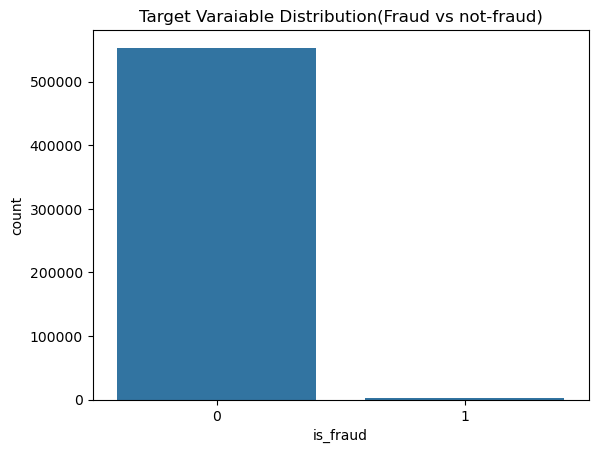

In [235]:
sns.countplot(x="is_fraud",data=df)
plt.title("Target Varaiable Distribution(Fraud vs not-fraud)")
plt.show()

In [236]:
#8)check Missing Values
df.isnull().sum()

Unnamed: 0               0
trans_date_trans_time    0
cc_num                   0
merchant                 0
category                 0
amt                      0
first                    0
last                     0
gender                   0
street                   0
city                     0
state                    0
zip                      0
lat                      0
long                     0
city_pop                 0
job                      0
dob                      0
trans_num                0
unix_time                0
merch_lat                0
merch_long               0
is_fraud                 0
dtype: int64

In [237]:
#9)understand categorical columns
df.select_dtypes(include='object').columns

Index(['trans_date_trans_time', 'merchant', 'category', 'first', 'last',
       'gender', 'street', 'city', 'state', 'job', 'dob', 'trans_num'],
      dtype='object')

In [238]:
#10)check unique columns
for col in df.select_dtypes(include='object').columns:
    print(col,df[col].unique())

trans_date_trans_time ['2020-06-21 12:14:25' '2020-06-21 12:14:33' '2020-06-21 12:14:53' ...
 '2020-12-31 23:59:15' '2020-12-31 23:59:24' '2020-12-31 23:59:34']
merchant ['fraud_Kirlin and Sons' 'fraud_Sporer-Keebler'
 'fraud_Swaniawski, Nitzsche and Welch' 'fraud_Haley Group'
 'fraud_Johnston-Casper' 'fraud_Daugherty LLC' 'fraud_Romaguera Ltd'
 'fraud_Reichel LLC' 'fraud_Goyette, Howell and Collier'
 'fraud_Kilback Group' 'fraud_Feil, Hilpert and Koss'
 'fraud_Gottlieb Group' 'fraud_Connelly-Carter' 'fraud_Bechtelar-Rippin'
 'fraud_Lubowitz-Walter' 'fraud_Welch, Rath and Koepp'
 'fraud_Hickle Group' 'fraud_Lang, Towne and Schuppe'
 'fraud_Morissette LLC' 'fraud_Prosacco LLC' 'fraud_Corwin-Romaguera'
 'fraud_Tillman LLC' 'fraud_Veum-Koelpin'
 'fraud_Watsica, Haag and Considine' 'fraud_Leannon-Ward'
 'fraud_Hintz, Bauch and Smith' 'fraud_Labadie LLC'
 'fraud_Eichmann, Hayes and Treutel' 'fraud_Leffler-Goldner'
 'fraud_Kautzer and Sons' 'fraud_Ernser-Feest'
 'fraud_Zemlak, Tillman and Cr

In [239]:
#11)Understand numerical columns
df.select_dtypes(include=['int64','float64']).columns

Index(['Unnamed: 0', 'cc_num', 'amt', 'zip', 'lat', 'long', 'city_pop',
       'unix_time', 'merch_lat', 'merch_long', 'is_fraud'],
      dtype='object')

In [240]:
#12) Check the duplicate rows
df.duplicated().sum()

np.int64(0)

### Step 4) Data Cleaning

In [241]:
#1)check missing values
df.isnull().sum()

Unnamed: 0               0
trans_date_trans_time    0
cc_num                   0
merchant                 0
category                 0
amt                      0
first                    0
last                     0
gender                   0
street                   0
city                     0
state                    0
zip                      0
lat                      0
long                     0
city_pop                 0
job                      0
dob                      0
trans_num                0
unix_time                0
merch_lat                0
merch_long               0
is_fraud                 0
dtype: int64

In [242]:
#2)Handle Incorrect/invalid values
df[df['amt']<0]

,Unnamed: 0,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,...,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud


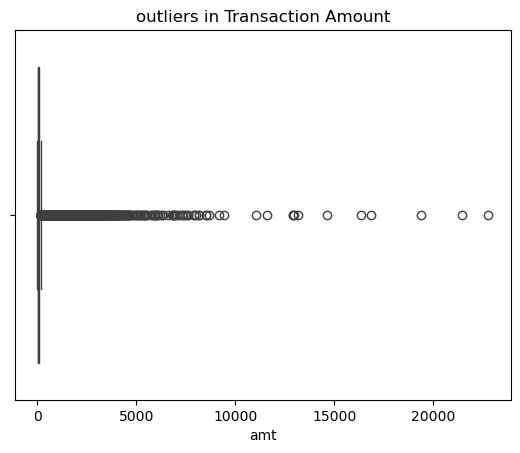

In [243]:
#3)Handle Outliers
#detecting outliers using boxplot
sns.boxplot(x=df['amt'])
plt.title("outliers in Transaction Amount")
plt.show()

In [244]:
#4)Remove outliers(IQR Method)
Q1=df['amt'].quantile(0.25)
Q3=df['amt'].quantile(0.75)
IQR=Q3-Q1
lower_bound=Q1-1.5*IQR
upper_bound=Q3=1.5*IQR
df=df[(df['amt']>=lower_bound)&(df['amt']<=upper_bound)]

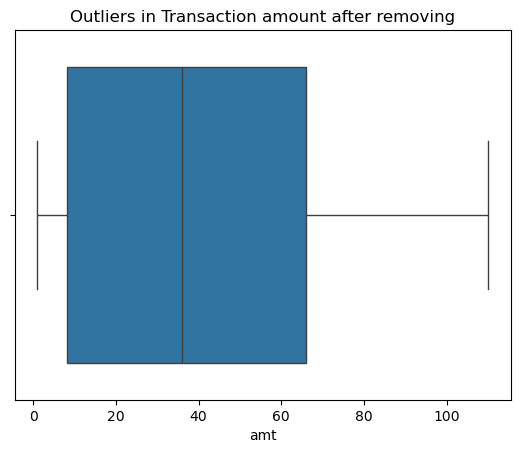

In [245]:
#5)To check the outliers are removed or not
sns.boxplot(x=df['amt'])
plt.title("Outliers in Transaction amount after removing")
plt.show()

In [246]:
#6)Drop irrelevant columns
df=df.drop(['cc_num','first','last'],axis=1)

In [247]:
#7)final data check
df.info()
df.describe()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
Index: 472027 entries, 0 to 555718
Data columns (total 20 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   Unnamed: 0             472027 non-null  int64  
 1   trans_date_trans_time  472027 non-null  object 
 2   merchant               472027 non-null  object 
 3   category               472027 non-null  object 
 4   amt                    472027 non-null  float64
 5   gender                 472027 non-null  object 
 6   street                 472027 non-null  object 
 7   city                   472027 non-null  object 
 8   state                  472027 non-null  object 
 9   zip                    472027 non-null  int64  
 10  lat                    472027 non-null  float64
 11  long                   472027 non-null  float64
 12  city_pop               472027 non-null  int64  
 13  job                    472027 non-null  object 
 14  dob                    472027 non-null  o

Unnamed: 0               0
trans_date_trans_time    0
merchant                 0
category                 0
amt                      0
gender                   0
street                   0
city                     0
state                    0
zip                      0
lat                      0
long                     0
city_pop                 0
job                      0
dob                      0
trans_num                0
unix_time                0
merch_lat                0
merch_long               0
is_fraud                 0
dtype: int64

### Step 5) Feature Engineering

In [248]:
df['trans_date_trans_time']=pd.to_datetime(df['trans_date_trans_time'])

In [249]:
df['hour']=df['trans_date_trans_time'].dt.hour
df['day']=df['trans_date_trans_time'].dt.day
df['month']=df['trans_date_trans_time'].dt.month

### Step 6) Encoding Categorical Variables

In [250]:
#1)Creating Age from BOB
df['dob']=pd.to_datetime(df['dob'])
df['age']=(pd.to_datetime('today')-df['dob']).dt.days//365

In [251]:
#2)Encode Categorical Variables
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
categorical_cols=['merchant','category','gender','city','state','job']
for cols in categorical_cols:
    df[cols]=le.fit_transform(df[cols])

In [252]:
df

,Unnamed: 0,trans_date_trans_time,merchant,category,amt,gender,street,city,state,zip,...,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud,hour,day,month,age
0,0,2020-06-21 12:14:25,319,10,2.86,1,351 Darlene Green,157,39,29209,...,1968-03-19,2da90c7d74bd46a0caf3777415b3ebd3,1371816865,33.986391,-81.200714,0,12,21,6,58
1,1,2020-06-21 12:14:33,591,10,29.84,0,3638 Marsh Union,16,43,84002,...,1990-01-17,324cc204407e99f51b0d6ca0055005e7,1371816873,39.450498,-109.960431,0,12,21,6,36
2,2,2020-06-21 12:14:53,611,5,41.28,0,9333 Valentine Point,61,33,11710,...,1970-10-21,c81755dbbbea9d5c77f094348a7579be,1371816893,40.495810,-74.196111,0,12,21,6,55
3,3,2020-06-21 12:15:15,222,9,60.05,1,32941 Krystal Mill Apt. 552,763,8,32780,...,1987-07-25,2159175b9efe66dc301f149d3d5abf8c,1371816915,28.812398,-80.883061,0,12,21,6,38
4,4,2020-06-21 12:15:17,292,13,3.19,1,5783 Evan Roads Apt. 465,247,21,49632,...,1955-07-06,57ff021bd3f328f8738bb535c302a31b,1371816917,44.959148,-85.884734,0,12,21,6,70
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
555713,555713,2020-12-31 23:58:34,490,6,17.00,0,28812 Charles Mill Apt. 628,609,1,36758,...,1970-11-20,6d04313bfe4b661b8ca2b6a499a320fe,1388534314,32.164145,-87.539669,0,23,31,12,55
555714,555714,2020-12-31 23:59:07,507,5,43.77,1,558 Michael Estates,442,23,63453,...,1966-02-13,9b1f753c79894c9f4b71f04581835ada,1388534347,39.946837,-91.333331,0,23,31,12,60
555716,555716,2020-12-31 23:59:15,496,7,86.88,0,144 Evans Islands Apt. 683,104,46,99323,...,1981-11-29,6c5b7c8add471975aa0fec023b2e8408,1388534355,46.658340,-119.715054,0,23,31,12,44
555717,555717,2020-12-31 23:59:24,75,13,7.99,1,7020 Doyle Stream Apt. 951,475,12,83643,...,1965-12-15,14392d723bb7737606b2700ac791b7aa,1388534364,44.470525,-117.080888,0,23,31,12,60


In [253]:
df.columns

Index(['Unnamed: 0', 'trans_date_trans_time', 'merchant', 'category', 'amt',
       'gender', 'street', 'city', 'state', 'zip', 'lat', 'long', 'city_pop',
       'job', 'dob', 'trans_num', 'unix_time', 'merch_lat', 'merch_long',
       'is_fraud', 'hour', 'day', 'month', 'age'],
      dtype='object')

In [254]:
#3)Drop unnecessary columns after feature engineering
df=df.drop(['street','merchant','city','job','trans_num','trans_date_trans_time','dob'],axis=1)

In [255]:
df.columns

Index(['Unnamed: 0', 'category', 'amt', 'gender', 'state', 'zip', 'lat',
       'long', 'city_pop', 'unix_time', 'merch_lat', 'merch_long', 'is_fraud',
       'hour', 'day', 'month', 'age'],
      dtype='object')

### Step 7) EDA Visualization(Before Splitting)

<function matplotlib.pyplot.show(close=None, block=None)>

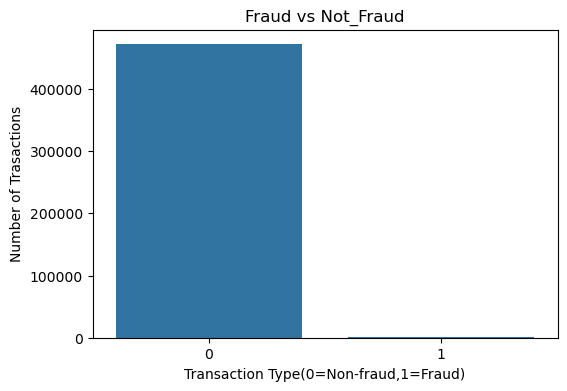

In [256]:
#1)Fraud vs Nont-fraud Distribution
plt.figure(figsize=(6,4))
sns.countplot(x="is_fraud",data=df)
plt.title("Fraud vs Not_Fraud")
plt.xlabel("Transaction Type(0=Non-fraud,1=Fraud)")
plt.ylabel("Number of Trasactions")
plt.show

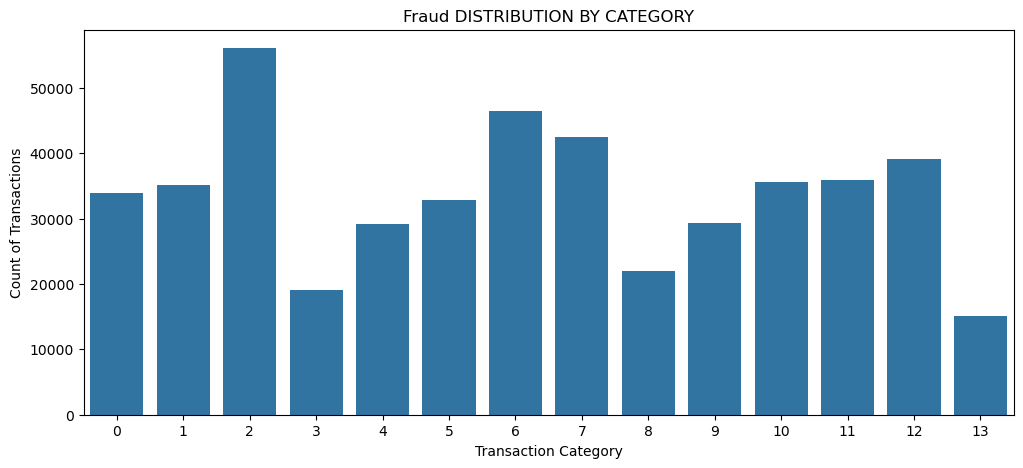

In [257]:
#2)Fraud by category
plt.figure(figsize=(12,5))
sns.countplot(x="category",data=df)
plt.title("Fraud DISTRIBUTION BY CATEGORY")
plt.xlabel("Transaction Category")
plt.ylabel("Count of Transactions")
plt.show()

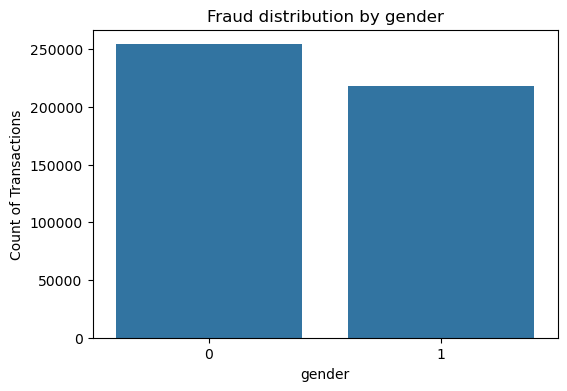

In [258]:
#3)Fraud by gender
plt.figure(figsize=(6,4))
sns.countplot(x='gender',data=df)
plt.title("Fraud distribution by gender")
plt.xlabel("gender")
plt.ylabel("Count of Transactions")
plt.show()

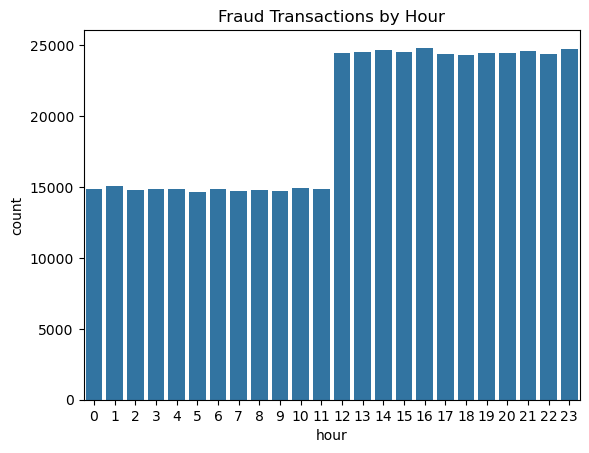

In [259]:
#4)Fraud vs Time
sns.countplot(x='hour',data=df)
plt.title("Fraud Transactions by Hour")
plt.show()

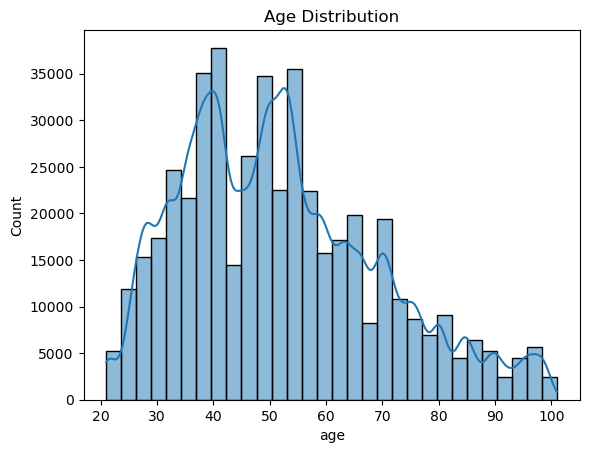

In [260]:
#5)Age Distribution
sns.histplot(df['age'],bins=30,kde=True)
plt.title("Age Distribution")
plt.show()

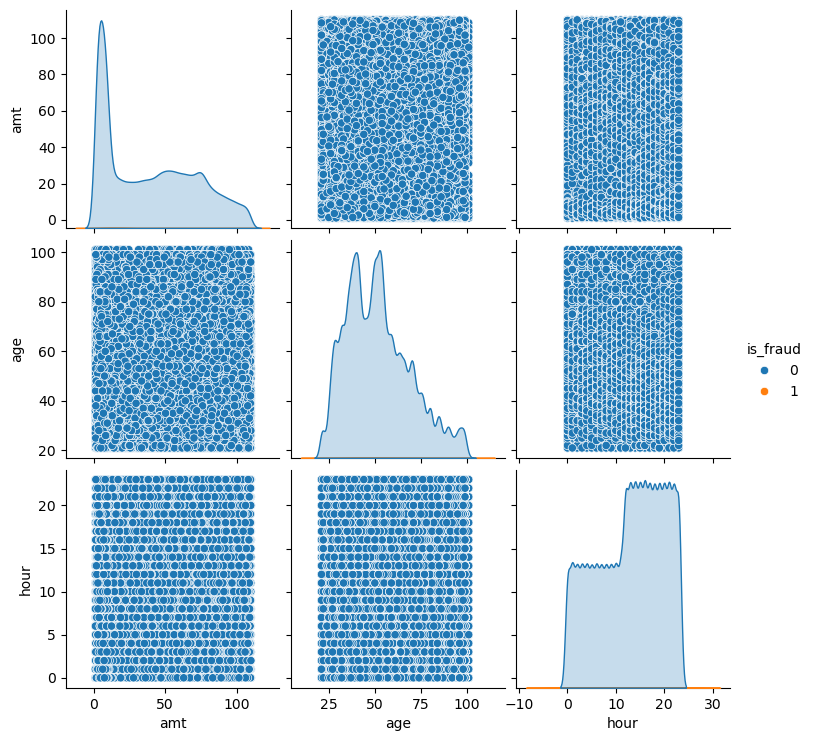

In [261]:
#7)Top features vs fraud
sns.pairplot(df[['amt','age','hour','is_fraud']],hue='is_fraud')
plt.show()

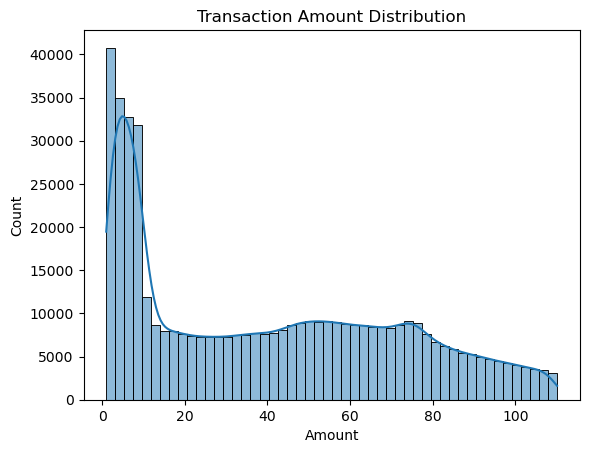

In [262]:
#8)Transaction Amount Distribution
sns.histplot(df['amt'],bins=50,kde=True)
plt.title("Transaction Amount Distribution")
plt.xlabel("Amount")
plt.show()

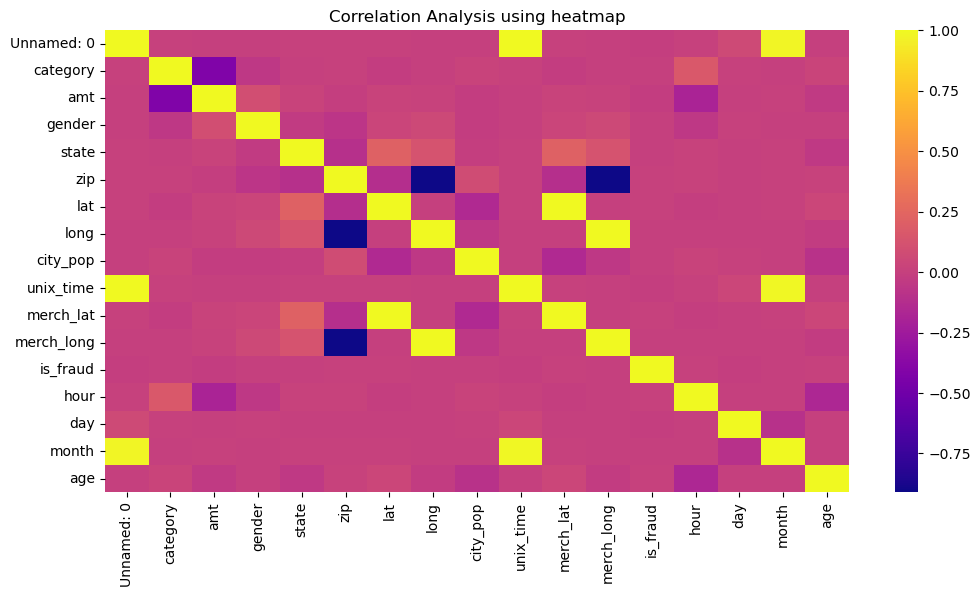

In [263]:
#9)Correlation heatmap
plt.figure(figsize=(12,6))
sns.heatmap(df.corr(),cmap='plasma',annot=False)
plt.title("Correlation Analysis using heatmap")
plt.show()

### Step 8) Define Features and Target

In [264]:
#1)Define feature variables
X=df.drop('is_fraud',axis=1)

In [265]:
#2)Define target variable
y=df['is_fraud']

### Step 9) Train-Test Split

In [266]:
#1)Splitting data for training and testing sets
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [267]:
#2)To know the shape
print("Training data shape:",X_train.shape)
print("Testing datashape:",X_test.shape)

Training data shape: (377621, 16)
Testing datashape: (94406, 16)


### STEP 10) Feature Scaling

In [268]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
X_train=scaler.fit_transform(X_train)
X_test=scaler.transform(X_test)

### Step 11) Model Building

In [269]:
#1)import required libraries
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix

In [270]:
#2)Initialize the Model
rf=RandomForestClassifier(n_estimators=100,criterion='gini',random_state=42)

In [271]:
#3)Train the model
rf.fit(X_train,y_train)

RandomForestClassifier(random_state=42)

In [272]:
#4)Make predictions
y_pred=rf.predict(X_test)
y_pred

array([0, 0, 0, ..., 0, 0, 0])

### Step 12) Model Evaluation

In [273]:
#1)Evaluate the model
accuracy=accuracy_score(y_test,y_pred)
print("Accuracy:",accuracy)

Accuracy: 0.9993220769866322


In [274]:
#2)classification Report
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     94317
           1       1.00      0.28      0.44        89

    accuracy                           1.00     94406
   macro avg       1.00      0.64      0.72     94406
weighted avg       1.00      1.00      1.00     94406



In [275]:
#3)Confusion Matrix
cm=confusion_matrix(y_test,y_pred)
print(cm)

[[94317     0]
 [   64    25]]


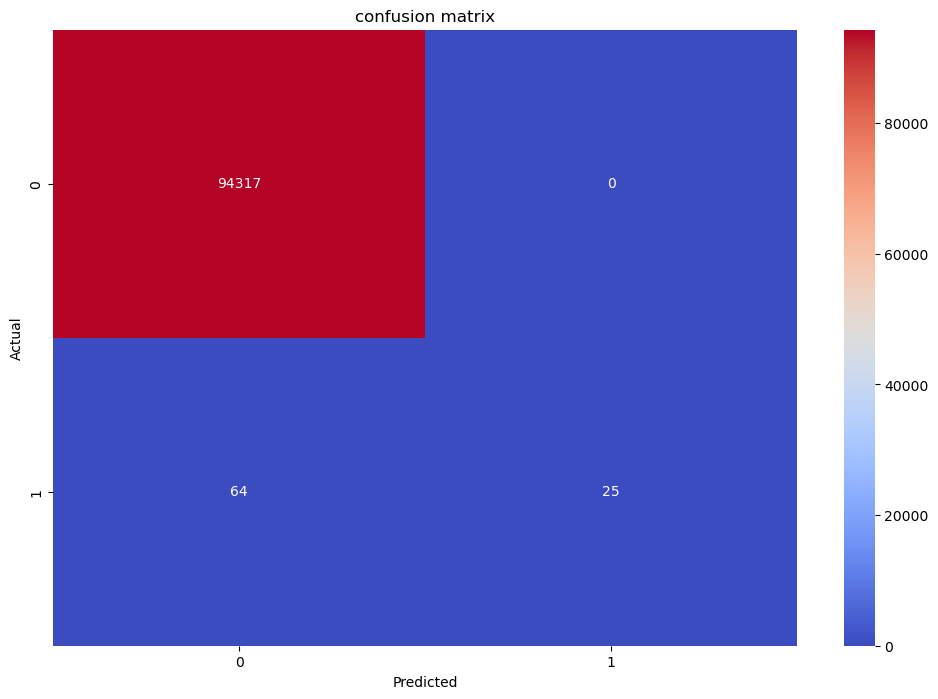

In [276]:
#4)Visualize confusion matrix
plt.figure(figsize=(12,8))
sns.heatmap(cm,annot=True,fmt='d',cmap='coolwarm')
plt.title("confusion matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

### Step 13) Visualization-After Splitting

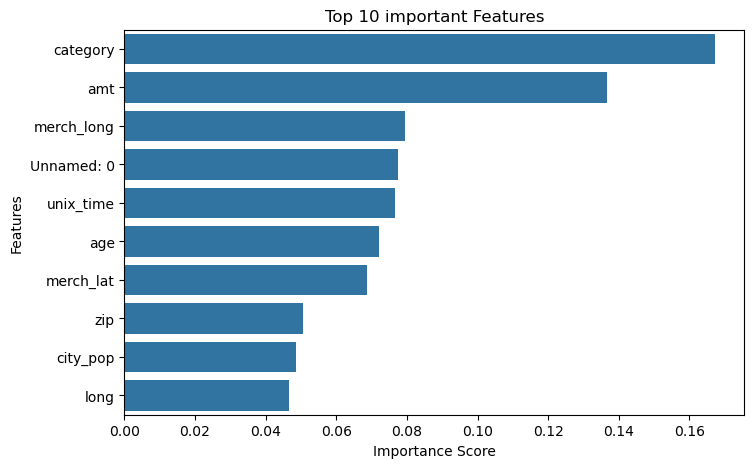

In [277]:
#1)Feature Importance
feature_importance=pd.DataFrame({'Feature':X.columns,'Importance':rf.feature_importances_}).sort_values(by='Importance',ascending=False)
plt.figure(figsize=(8,5))
sns.barplot(x="Importance",y="Feature",data=feature_importance.head(10))
plt.title("Top 10 important Features")
plt.xlabel("Importance Score")
plt.ylabel("Features")
plt.show()

### Step 14) Prediction System

In [278]:
#1)save trained model
import pickle
pickle.dump(rf,open('fraud_model.pkl','wb'))

In [279]:
#2)Load model for prediction
model=pickle.load(open('fraud_model.pkl','rb'))

In [280]:
#3)Build prediction Function
def predict_fraud(input_data):
    input_data=np.array(input_data).reshape(1,-1)
    input_data=scaler.transform(input_data)
    prediction=model.predict(input_data)
    if prediction[0]==1:
        return "Fraud Transaction"
    else:
        return "Legitimate Transaction"

In [281]:
X.shape

(472027, 16)

In [282]:
X.columns

Index(['Unnamed: 0', 'category', 'amt', 'gender', 'state', 'zip', 'lat',
       'long', 'city_pop', 'unix_time', 'merch_lat', 'merch_long', 'hour',
       'day', 'month', 'age'],
      dtype='object')

In [283]:
len(X.columns)

16

In [289]:
sample_input=pd.DataFrame([{'Unnamed: 0': 1,
    'category': 3,
    'amt': 5000,
    'gender': 1,
    'state': 2,
    'zip': 522001,
    'lat': 16.3,
    'long': 80.4,
    'city_pop': 200000,
    'unix_time': 1371816865,
    'merch_lat': 16.4,
    'merch_long': 80.5,
    'hour': 14,
    'day': 25,
    'month': 3,
    'age': 30}])
result=predict_fraud(sample_input)
print(result)

Legitimate Transaction
